In [1]:
from pathlib import Path
from src.db import get_connection
import sqlite3

import numpy as np
import pandas as pd

import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")


DATABASE_PATH = Path.home() / "HDD/Datasets/annas_archive_spotify_2025_07/spotify_clean_playlists.sqlite3"

cuda available
gpu ready


In [2]:
conn  = get_connection(DATABASE_PATH)
print("Connected to database")

Connected to database


In [3]:
def fetch_topn_playlist_tracks(conn, n):
    """Fetch all valid (playlist_rowid, track_rowid) pairs for the top N playlists
    by followers. DISTINCT ensures each track appears at most once per playlist.
    """
    query = """
        SELECT DISTINCT pt.playlist_rowid, pt.track_rowid
        FROM playlist_tracks pt
        WHERE pt.playlist_rowid IN (
            SELECT rowid 
            FROM playlists 
            ORDER BY followers_total 
            DESC LIMIT ?
        )
          AND pt.is_episode = 0
          AND pt.is_local = 0
          AND pt.track_rowid IS NOT NULL
    """
    return pd.read_sql(query, conn, params=[n])

N = 16384
_playlist_tracks = fetch_topn_playlist_tracks(conn, N)
_playlist_tracks

,playlist_rowid,track_rowid
0,3,1
1,3,4
2,3,8
3,3,9
4,3,10
...,...,...
18825387,9882406,64252
18825388,9882406,64265
18825389,9882406,71789
18825390,9882406,64263


In [4]:
def filter_kcore(pt: pd.DataFrame, k: int, min_playlist_len: int=2) -> pd.DataFrame:
    """
    Iteratively remove tracks appearing in fewer than k playlists and playlists
    with fewer than min_playlist_len tracks, until the result is stable.

    A playlist with only one remaining track produces no center-context pairs
    and is useless for skip-gram training, hence min_playlist_len=2 by default.
    """
    while True:
        n_before = len(pt)

        track_counts = pt["track_rowid"].value_counts()
        pt = pt[pt["track_rowid"].map(track_counts) >= k]

        playlist_counts = pt["playlist_rowid"].value_counts()
        pt = pt[pt["playlist_rowid"].map(playlist_counts) >= min_playlist_len]

        if len(pt) == n_before:
            break
    return pt.reset_index(drop=True)


playlist_tracks = filter_kcore(_playlist_tracks, k=2)
print(f"Interactions    : {len(playlist_tracks):,}")
print(f"Unique tracks   : {playlist_tracks['track_rowid'].nunique():,}")
print(f"Playlists       : {playlist_tracks['playlist_rowid'].nunique():,}")
print(f"Min playlist len: {playlist_tracks["playlist_rowid"].value_counts().min()}")
print(f"Min track it.   : {playlist_tracks["track_rowid"].value_counts().min()}")

Interactions    : 10,752,482
Unique tracks   : 625,784
Playlists       : 123,613
Min playlist len: 2
Min track it.   : 5


In [6]:
def build_vocab(pt: pd.DataFrame) -> pd.DataFrame:
    """Build a track_rowid → track_id mapping from the filtered interaction table.

    Assigns a contiguous integer index to each unique track_rowid. The resulting
    DataFrame is indexed by track_rowid for fast join-based lookups.
    """
    unique_tracks = pt["track_rowid"].unique()
    return pd.DataFrame({
        "track_rowid": unique_tracks,
        "track_id": np.arange(len(unique_tracks)), 
    }).set_index("track_rowid")

vocab = build_vocab(playlist_tracks)
vocab

,track_id
track_rowid,
1,0
4,1
8,2
9,3
10,4
...,...
231853846,625779
247606561,625780
247353840,625781


In [7]:
def map_vocab(pt: pd.DataFrame, vocab: pd.DataFrame) -> pd.DataFrame:
    """Replace track_rowid with the contiguous track_id from the vocab."""
    return pt.join(vocab, on="track_rowid").drop(columns=["track_rowid"])

playlist_tracks = map_vocab(playlist_tracks, vocab)
playlist_tracks

,playlist_rowid,track_id
0,3,0
1,3,1
2,3,2
3,3,3
4,3,4
...,...,...
10752477,9882406,380
10752478,9882406,209907
10752479,9882406,38935
10752480,9882406,38932


In [8]:
def build_weights(pt: pd.DataFrame) -> torch.Tensor:
    """Build a normalised negative-sampling weight tensor aligned to track_id order.

    Weights are proportional to freq^0.75 (word2vec unigram smoothing): frequent
    tracks are sampled more often as negatives, but the exponent dampens the
    dominance of the very top tracks.

    The returned tensor has shape (vocab_size,) where position i is the sampling
    weight for track_id=i, ready for torch.multinomial.
    """
    freq = pt["track_id"].value_counts()
    weights = torch.tensor((freq ** 0.75).sort_index().to_numpy(), dtype=torch.float32)
    return weights / weights.sum()

weights = build_weights(playlist_tracks)
weights

tensor([1.4730e-05, 1.1334e-06, 1.0986e-05,  ..., 7.2936e-07, 9.3872e-07,
        8.3623e-07])

In [9]:
def flatten(pt: pd.DataFrame) -> dict[int, list[int]]:
    """Group interactions into a playlist → [track_ids] dictionary."""
    return pt.groupby("playlist_rowid")["track_id"].apply(list).to_dict()

# Dataset

In [10]:
import random
import itertools
from warnings import warn
from typing import Iterable, Callable
from torch.utils.data import IterableDataset


def shuffle_buffer(iterable: Iterable, buffer_size: int):
    buf = []
    it = iter(iterable)

    # fill the buffer
    for item in itertools.islice(it, buffer_size):
        buf.append(item)

    # yield random elements, replacing with new ones from the stream
    for item in it:
        idx = random.randrange(len(buf))
        yield buf[idx]
        buf[idx] = item

    # drain whatever's left
    random.shuffle(buf)
    yield from buf


class SkipGramDataset(IterableDataset):
    def __init__(
        self,
        playlists_fn: Callable[[], Iterable[list[int]]],
        weights: torch.Tensor,
        W: int = 10,
        K: int = 5,
        sbuffer_size: int = 10_000,
    ):
        super().__init__()
        self.playlists_fn = playlists_fn
        self.weights = weights
        self.W = W
        self.K = K
        self.sbuffer_size = sbuffer_size
        self._epoch = 0

    def set_epoch(self, epoch: int) -> None:
        """Set the current epoch so that shuffling varies across epochs."""
        self._epoch = epoch

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()

        if worker_info is None:
            worker_gen = self.playlists_fn()
            seed = self._epoch
        else:
            # Combine the per-worker seed with the epoch so that:
            #   - different workers get different orderings (worker_info.seed varies per worker)
            #   - the same worker gets different orderings across epochs (_epoch varies)
            seed = worker_info.seed + self._epoch
            # This is the generator equivalent to `playlists[worker_info.id :: worker_info.num_workers]`
            worker_gen = itertools.islice(self.playlists_fn(), worker_info.id, None, worker_info.num_workers)

        # Seed both Python's random (used for shuffle) and PyTorch's RNG (used for multinomial)
        random.seed(seed)
        torch.manual_seed(seed)
        
        for playlist in shuffle_buffer(worker_gen, buffer_size=self.sbuffer_size):
            if len(playlist) < 2:
                warn("Encountered a playlist with fewer than two elements. Skipping.")
                continue
        
            n_pairs = 0
            for i in range(len(playlist)):
                lo = max(0, i - self.W)
                hi = min(len(playlist), i + self.W + 1)
                n_pairs += hi - lo - 1  # exclude i == j
            all_negatives = torch.multinomial(
                self.weights, n_pairs * self.K, replacement=True
            ).view(n_pairs, self.K)
        
            idx = 0
            for i, center in enumerate(playlist):
                lo = max(0, i - self.W)
                hi = min(len(playlist), i + self.W + 1)
                for j in range(lo, hi):
                    if j == i:
                        continue
                    context = playlist[j]
                    yield center, context, all_negatives[idx]
                    idx += 1

# Model

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Word2Vec(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int):
        super().__init__()
        self.embeddings_in = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        self.embeddings_out = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        nn.init.uniform_(self.embeddings_in.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.uniform_(self.embeddings_out.weight, -0.5 / embed_dim, 0.5 / embed_dim)

    def forward(
        self, center: torch.Tensor, context: torch.Tensor, negatives: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            pos_score: (batch,) dot product between center and context embeddings
            neg_score: (batch, K) dot products between center and each negative embedding
        """
        ecenter = self.embeddings_in(center)
        econtext = self.embeddings_out(context)
        enegative = self.embeddings_out(negatives)

        pos_score = (ecenter * econtext).sum(dim=1)
        neg_score = torch.bmm(enegative, ecenter.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score

    @property
    def track_embeddings(self) -> torch.Tensor:
        return self.embeddings_in.weight.detach()

# Loss

In [12]:
def skipgram_loss(
    pos_score: torch.Tensor, neg_score: torch.Tensor
) -> torch.Tensor:
    """Negative-sampling loss for skip-gram Word2Vec."""
    pos_loss = F.logsigmoid(pos_score)
    neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
    return -(pos_loss + neg_loss).mean()

# Training

In [13]:
np.random.seed(0)

playlist_unique = playlist_tracks["playlist_rowid"].unique()
np.random.shuffle(playlist_unique)
playlist_train = playlist_unique[:int(0.9 * len(playlist_unique))]
train_mask = playlist_tracks["playlist_rowid"].isin(playlist_train)
train_df = playlist_tracks[train_mask].reset_index(drop=True)
valid_df = playlist_tracks[~train_mask].reset_index(drop=True)

print(f"train amounts to {100 * len(train_df) / len(playlist_tracks):.1f} % of the dataset")

train amounts to 89.9 % of the dataset


In [39]:
from torch.utils.data import DataLoader

train_dataset = SkipGramDataset(
    playlists_fn=lambda: [*flatten(train_df).values()],
    W=5,
    weights=weights,
    sbuffer_size=len(flatten(train_df)),
)
valid_dataset = SkipGramDataset(
    playlists_fn=lambda: [*flatten(valid_df).values()],
    W=5,
    weights=weights,
    sbuffer_size=len(flatten(valid_df)),
)
train = DataLoader(train_dataset, batch_size=512, num_workers=20, pin_memory=True, persistent_workers=True)
valid = DataLoader(valid_dataset, batch_size=512, num_workers=20, pin_memory=True, persistent_workers=True)

In [15]:
import time
from torch.optim import SparseAdam

EMBED_DIM = 128
NEPOCHS = 10
LR = 1e-3
device = torch.device("cuda")

model = Word2Vec(vocab_size=len(vocab), embed_dim=EMBED_DIM)
model = model.to(device)
optimizer = SparseAdam(model.parameters(), lr=LR)

history = {"train": [], "valid": []}

for epoch in range(NEPOCHS):
    t0 = time.perf_counter()

    model.train()
    train_dataset.set_epoch(epoch)
    nt, tloss_epoch = 0, 0.
    for nt, batch in enumerate(train):
        optimizer.zero_grad()
        batch = [x.to(device) for x in batch]
        pos, neg = model(*batch)
        loss = skipgram_loss(pos, neg)
        loss.backward()
        optimizer.step()
        tloss_epoch += loss.item()

    t1 = time.perf_counter()

    model.eval()
    valid_dataset.set_epoch(epoch)
    nv, vloss_epoch = 0, 0.
    with torch.no_grad():
        for nv, batch in enumerate(valid):
            batch = [x.to(device) for x in batch]
            vloss_epoch += skipgram_loss(*model(*batch)).item()

    t2 = time.perf_counter()

    train_loss = tloss_epoch / nt
    valid_loss = vloss_epoch / nv
    history["train"].append(train_loss)
    history["valid"].append(valid_loss)

    w = len(str(NEPOCHS))
    print(
        f"epoch {epoch+1:{w}}/{NEPOCHS}"
        f"  │  train {train_loss:.4f}"
        f"  valid {valid_loss:.4f}"
        f"  │  {t2-t0:.0f}s  (train {t1-t0:.0f}s  valid {t2-t1:.0f}s)"
    )

epoch  1/10  │  train 2.8719  valid 2.3606  │  409s  (train 387s  valid 22s)
epoch  2/10  │  train 2.0987  valid 2.0265  │  416s  (train 394s  valid 22s)
epoch  3/10  │  train 1.8201  valid 1.8229  │  413s  (train 391s  valid 22s)
epoch  4/10  │  train 1.6129  valid 1.6613  │  413s  (train 391s  valid 22s)
epoch  5/10  │  train 1.4416  valid 1.5261  │  417s  (train 394s  valid 22s)
epoch  6/10  │  train 1.3012  valid 1.4135  │  412s  (train 390s  valid 22s)
epoch  7/10  │  train 1.1874  valid 1.3215  │  419s  (train 396s  valid 23s)
epoch  8/10  │  train 1.0946  valid 1.2472  │  419s  (train 397s  valid 22s)
epoch  9/10  │  train 1.0177  valid 1.1872  │  417s  (train 395s  valid 22s)
epoch 10/10  │  train 0.9534  valid 1.1385  │  419s  (train 398s  valid 22s)


In [44]:
if (low_on_memory := False):
    train._iterator._shutdown_workers()
    valid._iterator._shutdown_workers()

### Recap

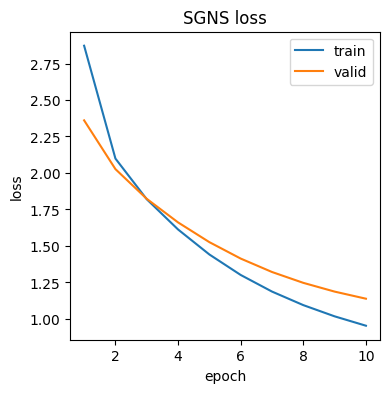

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
epochs = range(1, len(history["train"]) + 1)
ax.plot(epochs, history["train"], label="train")
ax.plot(epochs, history["valid"], label="valid")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.set_title("SGNS loss"); ax.legend()
plt.show()

# Qualitative checks

In [31]:
# Load track lookup, keep only columns we need, inner-join with vocab
lookup = pd.read_parquet(
    "../data/playlist/track_lookup.parquet",
    columns=["track_rowid", "track_name", "artist_name", "track_popularity"],
)
lookup = lookup.merge(vocab, on="track_rowid", how="inner")
print(f"{len(lookup):,} tracks in lookup (should match vocab size {len(vocab):,})")
lookup.head()

625,784 tracks in lookup (should match vocab size 625,784)


,track_rowid,track_name,artist_name,track_popularity,track_id
0,1,The Giver,Chappell Roan,89,0
1,4,Crash,NOTD,56,1
2,7,WIFI,NOTD,55,34980
3,8,SMOKE THE PAIN AWAY,Calvin Harris,75,2
4,9,Leyla,Robin Kadir,45,3


In [23]:
# L2-normalise embeddings once — cosine sim becomes a simple matmul
emb = model.track_embeddings.to(device)
emb_norm = emb / emb.norm(dim=1, keepdim=True)


def find_neighbours(query: str, k: int = 10) -> pd.DataFrame:
    """Find top-k nearest neighbours by cosine similarity.

    `query` is matched case-insensitively against track_name. If multiple tracks
    match, the most popular one is used.
    """
    matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
    if matches.empty:
        print(f"No tracks matching '{query}'")
        return pd.DataFrame()

    row = matches.sort_values("track_popularity", ascending=False).iloc[0]
    tid = row["track_id"]
    print(f"Query: {row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})")

    sims = (emb_norm[tid] @ emb_norm.T).cpu().numpy()
    top_idx = np.argsort(sims)[::-1][1 : k + 1]  # skip self

    result = lookup[lookup["track_id"].isin(top_idx)].copy()
    result["similarity"] = sims[result["track_id"].values]
    result = result.sort_values("similarity", ascending=False)
    return result[["track_name", "artist_name", "track_popularity", "similarity"]]

In [24]:
queries = [
    "Love Will Tear Us Apart",   # Joy Division — post-punk
    "Smells Like Teen Spirit",    # Nirvana — grunge
    "Raining Blood",              # Slayer — thrash metal
    "Windowlicker",               # Aphex Twin — IDM
    "N.Y. State of Mind",         # Nas — east coast hip hop
    "Nuthin' But A 'G' Thang",   # Dr. Dre — west coast hip hop
    "Bela Lugosi's Dead",         # Bauhaus — post-punk/goth
    "Just Like Heaven",           # The Cure — post-punk/new wave
    "Once in a Lifetime",         # Talking Heads — new wave
    "Be Quiet and Drive",         # Deftones — alt metal
]

for q in queries:
    display(find_neighbours(q))
    print()

Query: Love Will Tear Us Apart - 2020 Remaster — Joy Division  (pop 70)


,track_name,artist_name,track_popularity,similarity
355509,Transmission - 2020 Digital Remaster,Joy Division,57,0.911608
19609,Disorder - 2007 Remaster,Joy Division,67,0.900697
405443,Close to Me - 2006 Remaster,The Cure,62,0.898583
19620,Here Comes Your Man,Pixies,71,0.895820
271306,Lullaby - 2010 Remaster,The Cure,58,0.892131
350338,A Forest,The Cure,68,0.889907
43770,Inbetween Days,The Cure,67,0.888399
4290,Some Girls Are Bigger Than Others - 2011 Remaster,The Smiths,60,0.885224
350542,The Killing Moon,Echo & the Bunnymen,63,0.884787
339514,The Lovecats,The Cure,51,0.883533



Query: Smells Like Teen Spirit — Nirvana  (pop 84)


,track_name,artist_name,track_popularity,similarity
7625,Come As You Are,Nirvana,82,0.856442
204520,Enter Sandman - Remastered 2021,Metallica,72,0.810520
7627,Lithium,Nirvana,74,0.807270
613958,Zombie - 2025 Remastered,The Cranberries,2,0.804068
618912,Stepping on Glass - 2025 Remastered Version,Lightcap's All-Stars,2,0.798527
617541,Girl Like Her,Kids That Fly,4,0.793480
204523,Nothing Else Matters - Remastered 2021,Metallica,70,0.790814
7624,In Bloom,Nirvana,70,0.786767
613369,Diamonds in the Sky,Lavendine,13,0.785131
22065,Paranoid - 2009 Remaster,Black Sabbath,79,0.781947



Query: Raining Blood — Slayer  (pop 70)


...

,track_name,artist_name,track_popularity,similarity
276824,Love Will Tear Us Apart - 2020 Remaster,Joy Division,70,0.869549
43770,Inbetween Days,The Cure,67,0.865380
19620,Here Comes Your Man,Pixies,71,0.865016
74098,Lovesong - Remastered,The Cure,70,0.863280
4286,Bigmouth Strikes Again - 2011 Remaster,The Smiths,72,0.851935
405443,Close to Me - 2006 Remaster,The Cure,62,0.849823
353342,In Between Days - 2006 Remaster,The Cure,58,0.848725
274686,"Head Over Heels - Dave Bascombe 7"" N.Mix",Tears For Fears,72,0.847985
41596,A Little Respect,Erasure,71,0.844470
438009,Head Over Heels,Tears For Fears,47,0.844357



Query: Once in a Lifetime - 2005 Remaster — Talking Heads  (pop 68)


,track_name,artist_name,track_popularity,similarity
19692,This Town,The Go-Go's,41,0.885630
19697,Making Plans For Nigel,XTC,58,0.875228
19699,Pump It Up - 2021 Remaster,Elvis Costello & The Attractions,58,0.872251
349982,The Perfect Kiss - 2015 Remaster,New Order,49,0.867085
405443,Close to Me - 2006 Remaster,The Cure,62,0.867047
348256,(Nothing But) Flowers - 2005 Remaster,Talking Heads,46,0.862968
346402,Brass in Pocket - 2006 Remaster,Pretenders,59,0.862873
355324,Once in a Lifetime,Talking Heads,59,0.862617
350143,Whip It,DEVO,52,0.860490
349686,Life During Wartime - 2005 Remaster,Talking Heads,57,0.859723



Query: Be Quiet and Drive (Far Away) — Deftones  (pop 80)


,track_name,artist_name,track_popularity,similarity
35196,Rosemary,Deftones,76,0.926324
18837,My Own Summer (Shove It),Deftones,79,0.921938
265625,Beware,Deftones,70,0.921280
24086,Digital Bath,Deftones,73,0.920896
18840,Around the Fur,Deftones,69,0.918093
351567,Beauty School,Deftones,67,0.915953
265626,Cherry Waves,Deftones,78,0.912513
351571,Risk,Deftones,69,0.910919
265628,Xerces,Deftones,69,0.907079
24091,Knife Prty,Deftones,65,0.903426


## Curated genre UMAP

In [25]:
# Parse genre_artists.txt → {genre: [artist_name]}
genre_artists = {}
current_genre = None
with open("genre_artists.txt") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("#"):
            current_genre = line[1:].strip()
            genre_artists[current_genre] = []
        else:
            genre_artists[current_genre].append(line)

for g, artists in genre_artists.items():
    print(f"{g}: {len(artists)} artists")

new-wave: 14 artists
post-punk: 14 artists
70s-punk: 13 artists
grunge: 13 artists
thrash-metal: 13 artists
black-metal: 13 artists
dark-wave: 13 artists
90s-west-coast-hip-hop: 13 artists
90s-east-coast-hip-hop: 13 artists
conscious-hip-hop: 13 artists
IDM: 13 artists


In [26]:
# Join curated artists with lookup to get their tracks + track_ids
rows = []
for genre, artists in genre_artists.items():
    for artist in artists:
        mask = lookup["artist_name"].str.lower() == artist.lower()
        matched = lookup[mask]
        for _, row in matched.iterrows():
            rows.append({
                "genre": genre,
                "artist_name": row["artist_name"],
                "track_name": row["track_name"],
                "track_id": row["track_id"],
            })

genre_df = pd.DataFrame(rows)
print(f"{len(genre_df):,} tracks matched across {genre_df['genre'].nunique()} genres")
print(f"{genre_df['artist_name'].str.lower().nunique()} unique artists matched")
print()
print(genre_df["genre"].value_counts().to_string())

6,423 tracks matched across 11 genres
137 unique artists matched

genre
90s-east-coast-hip-hop    1109
90s-west-coast-hip-hop    1028
new-wave                   882
thrash-metal               733
grunge                     664
conscious-hip-hop          605
post-punk                  559
70s-punk                   323
IDM                        261
dark-wave                  201
black-metal                 58


In [28]:
import umap

# Extract embeddings for the curated tracks
track_ids = genre_df["track_id"].values
genre_emb = emb_norm[track_ids].cpu().numpy()

reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42)
coords = reducer.fit_transform(genre_emb)
genre_df["umap_x"] = coords[:, 0]
genre_df["umap_y"] = coords[:, 1]
print(f"UMAP done — {len(coords)} points")

/home/peppe/Dropbox/Progetti/ml/spotify-rec/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done — 6423 points


/tmp/ipykernel_525351/2068404240.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(genres))


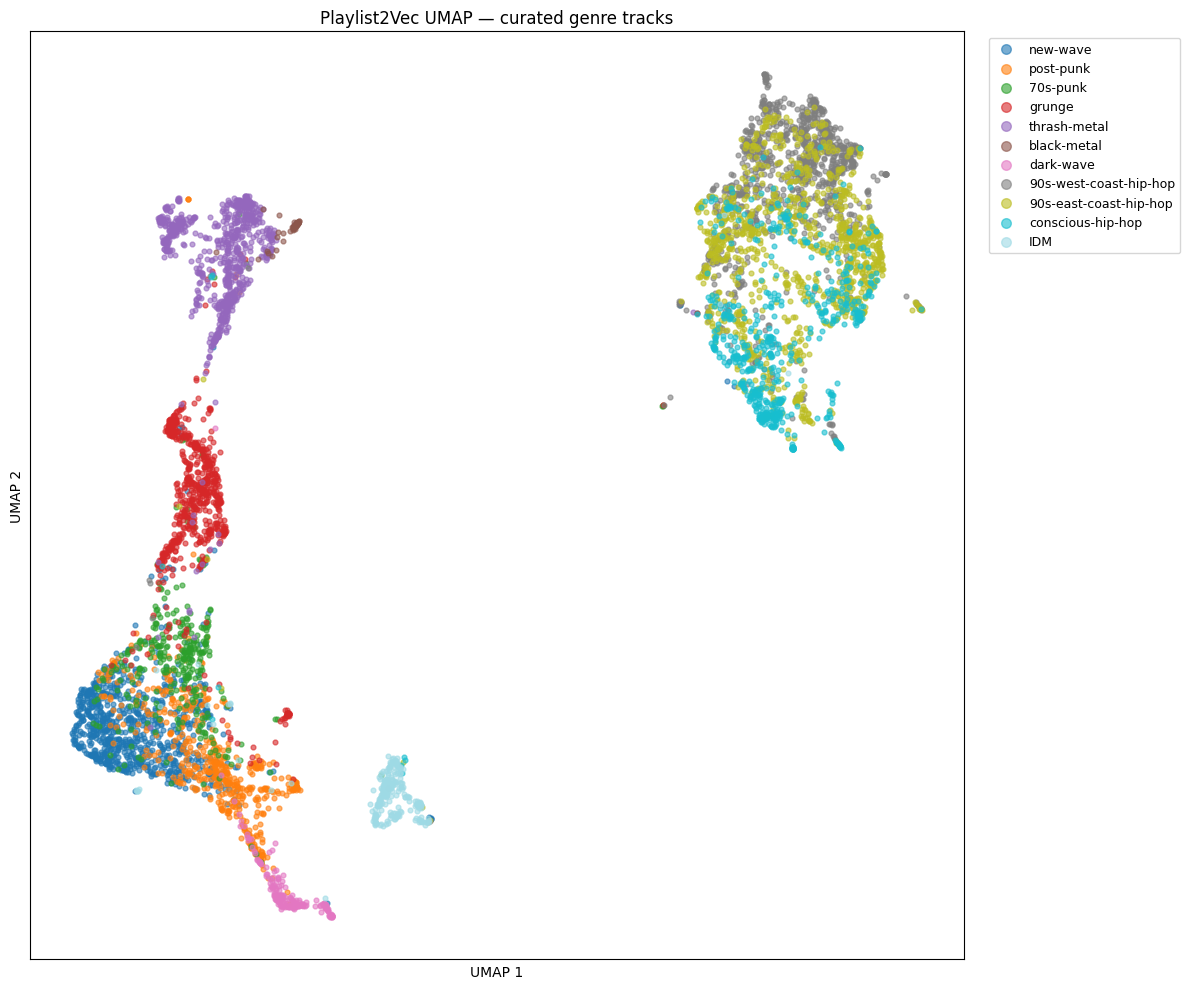

In [29]:
fig, ax = plt.subplots(figsize=(12, 10))

genres = genre_df["genre"].unique()
cmap = plt.cm.get_cmap("tab20", len(genres))

for i, genre in enumerate(genres):
    subset = genre_df[genre_df["genre"] == genre]
    ax.scatter(
        subset["umap_x"], subset["umap_y"],
        c=[cmap(i)], label=genre, s=12, alpha=0.6,
    )

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, markerscale=2)
ax.set_title("Playlist2Vec UMAP — curated genre tracks")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()